In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset metrics
data = {
    "Final Year": {
        "YOLOv8": [0.8125, 0.7331, 0.7883, 0.56, 11127906, 11.1],   # precision, recall, mAP@50, mAP@50_95, parameter, time
        "DyCAF-Net": [0.8221, 0.7966, 0.8232, 0.5743, 11127906, 11.2]
    },
    "Traffic Density": {
        "YOLOv8": [0.7695, 0.7708, 0.8168, 0.5468, 11128680, 11.4],
        "DyCAF-Net": [0.7538, 0.7788, 0.8176, 0.5466, 11128680, 13.5]
    },
    "City Scapes": {
        "YOLOv8": [0.5553, 0.23073, 0.2518, 0.1565, 11127906, 6.7],
        "DyCAF-Net": [0.5251, 0.2522, 0.2509, 0.1530, 11127906, 6.3]
    },
    "Mask Wearing": {
        "YOLOv8": [0.8467, 0.8295, 0.8912, 0.6073, 11126358, 11.9],
        "DyCAF-Net": [0.8582, 0.8299, 0.9266, 0.6424, 11126358, 13.0]
    },
    "Furniture": {
        "YOLOv8": [0.9752, 0.9894, 0.9922, 0.8965, 11126745, 13.1],
        "DyCAF-Net": [0.9706, 0.9891, 0.9941, 0.8691, 11126745, 14.3]
    },
    "Construction Safety": {
        "YOLOv8": [0.8498, 0.7996, 0.8853, 0.4986, 11127519, 11.0],
        "DyCAF-Net": [0.8545, 0.8583, 0.9023, 0.5195, 11127519, 11.9]
    },
    "Peanuts": {
        "YOLOv8": [0.9999, 1.0000, 0.9950, 0.9197, 11126358, 32.5],
        "DyCAF-Net": [0.9999, 1.0000, 0.9950, 0.9263, 11126358, 38.2]
    },
    "Road Signs": {
        "YOLOv8": [0.9361, 0.9321, 0.9680, 0.8186, 11133711, 14.4],
        "DyCAF-Net": [0.9377, 0.9295, 0.9676, 0.8200, 11133711, 12.6]
    },
    "Street Work": {
        "YOLOv8": [0.7016, 0.8126, 0.7117, 0.4666, 11128680, 13.1],
        "DyCAF-Net": [0.6936, 0.7737, 0.6943, 0.4575, 11128680, 13.6]
    },
    "Wine Labels": {
        "YOLOv8": [0.7259, 0.6167, 0.6352, 0.4519, 11130228, 10.3],
        "DyCAF-Net": [0.7557, 0.6087, 0.6435, 0.4557, 11130228, 12.0]
    },
    "Axial MRI": {
        "YOLOv8": [0.4988, 0.6896, 0.5874, 0.4270, 11126358, 16.0],
        "DyCAF-Net": [0.8090, 0.5841, 0.6749, 0.4815, 11126358, 16.5]
    },
    "X-Ray": {
        "YOLOv8": [0.9043, 0.8540, 0.8520, 0.5757, 11130228, 18.5],
        "DyCAF-Net": [0.9105, 0.8717, 0.8593, 0.5774, 11130228, 13.6]
    },
    "Animals": {
        "YOLOv8": [0.8965, 0.7994, 0.8927, 0.6974, 11129454, 9.8],
        "DyCAF-Net": [0.8541, 0.8429, 0.8970, 0.7305, 11129454, 13.5]
    }
}

# Initialize Seaborn styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "DejaVu Sans"  # Set fallback font

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set default font color and other styles
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',  # Also ensures the axes spines are black
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})


# Critical Calculation and Trend

In [6]:
# 1. Critical Calculations
def calculate_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall)

# Calculate metrics
for dataset in data:
    # F1 Score
    data[dataset]["YOLOv8"].append(calculate_f1(data[dataset]["YOLOv8"][0], data[dataset]["YOLOv8"][1]))
    data[dataset]["DyCAF-Net"].append(calculate_f1(data[dataset]["DyCAF-Net"][0], data[dataset]["DyCAF-Net"][1]))

    # mAP@50-95 Improvement
    mAP_improvement = ((data[dataset]["DyCAF-Net"][3] - data[dataset]["YOLOv8"][3]) / data[dataset]["YOLOv8"][3]) * 100
    data[dataset]["mAP_improvement"] = mAP_improvement

# 2. Trend Analysis and Visualization
datasets = list(data.keys())

# Visualization

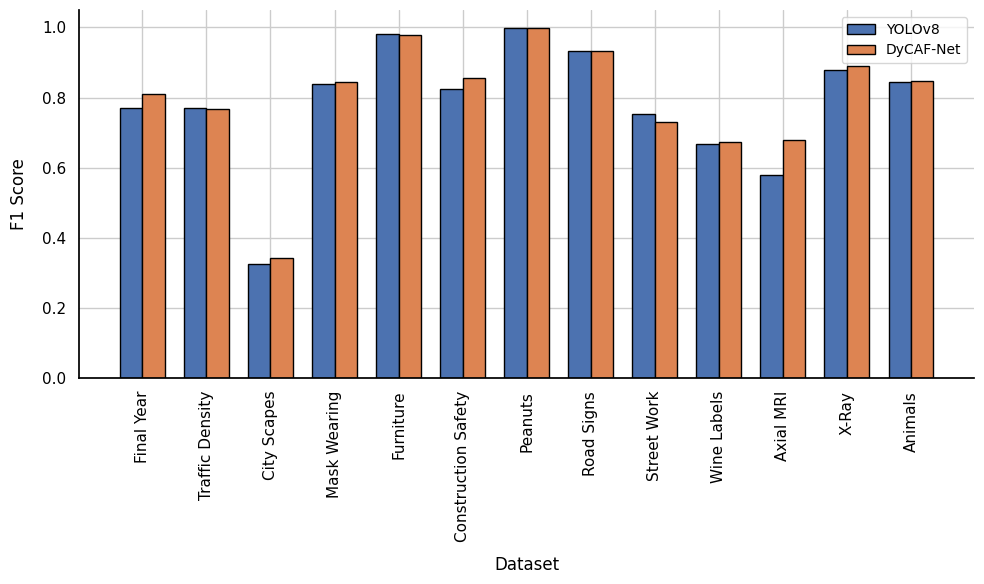

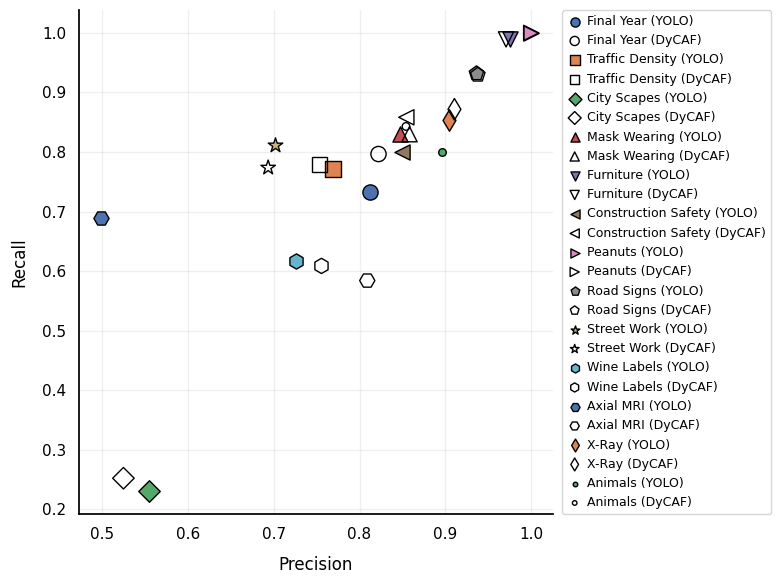

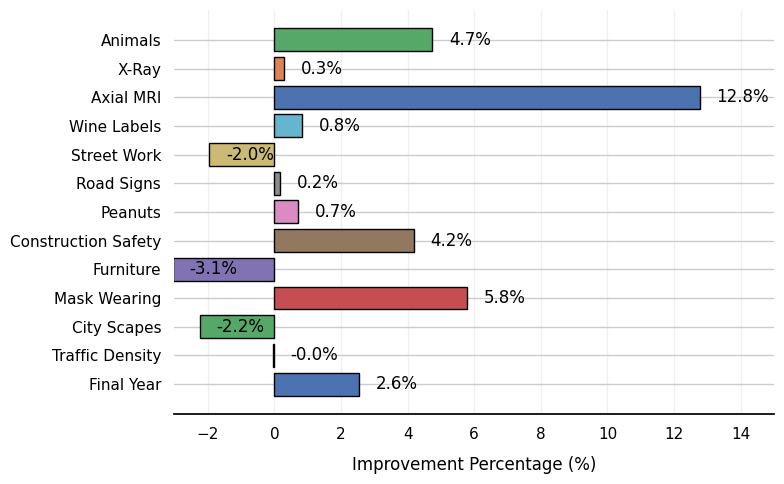

In [7]:
# Figure 1a: F1-Score Comparison
plt.figure(figsize=(10, 6), dpi=100)
bar_width = 0.35
index = np.arange(len(datasets))

f1_yolo = [data[d]["YOLOv8"][6] for d in datasets]
f1_dycaf = [data[d]["DyCAF-Net"][6] for d in datasets]

bars1 = plt.bar(index, f1_yolo, bar_width, label='YOLOv8', edgecolor='black')
bars2 = plt.bar(index + bar_width, f1_dycaf, bar_width, label='DyCAF-Net', edgecolor='black')

# plt.title('F1-Score Comparison Across Datasets', fontsize=14, pad=20)
plt.xlabel('Dataset', fontsize=12, labelpad=10)
plt.ylabel('F1 Score', fontsize=12, labelpad=10)
plt.xticks(index + bar_width/2, datasets, rotation=90)
plt.legend(frameon=True, fontsize=10)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()

plt.tight_layout()
plt.savefig("ablation1.pdf")
plt.show()


# Figure 1b: Precision-Recall Trade-off
plt.figure(figsize=(8, 6), dpi=100)
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'd', '.']

for i, dataset in enumerate(datasets):
    plt.scatter(data[dataset]["YOLOv8"][0], data[dataset]["YOLOv8"][1],
                s=120, marker=markers[i % len(markers)], edgecolor='black',
                label=f'{dataset} (YOLO)')
    plt.scatter(data[dataset]["DyCAF-Net"][0], data[dataset]["DyCAF-Net"][1],
                s=120, marker=markers[i % len(markers)], edgecolor='black', facecolors='none',
                label=f'{dataset} (DyCAF)')

# plt.title('Precision-Recall Trade-off', fontsize=14, pad=20)
plt.xlabel('Precision', fontsize=12, labelpad=10)
plt.ylabel('Recall', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.3)

# Adjust legend: smaller font and smaller marker size
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    markerscale=0.6,         # ↓ Reduce marker size in legend
    handlelength=1.2,        # Optional: tweak line length
    handletextpad=0.4,       # Optional: tweak spacing
    borderaxespad=0.,
    frameon=True
)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()
plt.tight_layout()
plt.savefig("ablation2.pdf")
plt.show()


# Figure 2a: mAP@50-95 Improvement
plt.figure(figsize=(8, 5), dpi=100)
improvements = [data[d]["mAP_improvement"] for d in datasets]

bars = plt.barh(datasets, improvements, color=sns.color_palette("deep"), edgecolor='black')
# plt.title('mAP@50-95 Improvement (%) Over YOLOv8', fontsize=14, pad=20)
plt.xlabel('Improvement Percentage (%)', fontsize=12, labelpad=10)
plt.xlim(-3, 15)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             va='center', ha='left')

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine(left=True)
plt.tight_layout()
plt.savefig("ablation3.pdf")
plt.show()

# Benchmarking (Performance Comparison)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = {
    "Final Year": {
        "DyCAF-Net": [0.8221, 0.7966, 0.8232, 0.5743, 11127906, 11.2],
        "DeepWalk": [0.7848, 0.6745, 0.7376, 0.5030, 11127906, 13.0],
        "Node2Vec": [0.6922, 0.7780, 0.7768, 0.5510, 11127906, 11.1],
        "M²DNE": [0.8085, 0.7487, 0.7916, 0.5569, 11127906, 10.8],
        "DyTriad": [0.8035, 0.7097, 0.7779, 0.5475, 11127906, 14.2],
        "MPNN": [0.6922, 0.7780, 0.7768, 0.5510, 11127906, 11.1],
        "JODIE": [0.6922, 0.7780, 0.7768, 0.5510, 11127906, 11.2],
        "EvolveGCN": [0.7849, 0.6593, 0.7230, 0.5056, 11127906, 13.9],
        "TGAT": [0.7790, 0.6620, 0.7270, 0.4900, 11127906, 11.0],
        "SpikeNet": [0.6940, 0.6980, 0.7130, 0.4780, 3006818, 5.3]
    },
    "City Scapes": {
        "DyCAF-Net": [0.5251, 0.2522, 0.2509, 0.1530, 11127906, 6.3],
        "DeepWalk": [0.6806, 0.1822, 0.2061, 0.1280, 11127906, 6.4],
        "Node2Vec": [0.5251, 0.2522, 0.2509, 0.1530, 11127906, 6.7],
        "M²DNE": [0.5458, 0.2356, 0.2473, 0.1527, 11127906, 7.0],
        "DyTriad": [0.5458, 0.2356, 0.2473, 0.1527, 11127906, 6.9],
        "MPNN": [0.5251, 0.2522, 0.2509, 0.1530, 11127906, 7.0],
        "JODIE": [0.5251, 0.2522, 0.2509, 0.1530, 11127906, 6.5],
        "EvolveGCN": [0.5251, 0.2400, 0.2299, 0.1446, 11127906, 6.6],
        "TGAT": [0.7620, 0.1690, 0.2050, 0.1260, 11127906, 6.4],
        "SpikeNet": [0.6080, 0.1670, 0.1830, 0.1110, 3006818, 3.7]
    },
    "Traffic Density": {
        "DyCAF-Net": [0.7538, 0.7788, 0.8176, 0.5466, 11128680, 13.5],
        "DeepWalk": [0.6824, 0.7508, 0.7683, 0.4920, 11128680, 12.2],
        "Node2Vec": [0.7577, 0.7821, 0.8178, 0.5482, 11128680, 11.2],
        "M²DNE": [0.7748, 0.7893, 0.8319, 0.5597, 11128680, 10.9],
        "DyTriad": [0.7599, 0.7825, 0.8209, 0.5521, 11128680, 12.5],
        "MPNN": [0.7577, 0.7821, 0.8178, 0.5482, 11128680, 11.2],
        "JODIE": [0.7577, 0.7821, 0.8178, 0.5482, 11128680, 11.1],
        "EvolveGCN": [0.7077, 0.7509, 0.7808, 0.5016, 11128680, 11.2],
        "TGAT": [0.6960, 0.7440, 0.7710, 0.4940, 11128680, 11.1],
        "SpikeNet": [0.6510, 0.7310, 0.7430, 0.4610, 3007208, 5.5]
    },
    "Animals": {
        "DyCAF-Net": [0.8541, 0.8429, 0.8970, 0.7305, 11129454, 13.5],
        "DeepWalk": [0.5040, 0.4525, 0.4539, 0.2811, 11129454, 12.3],
        "Node2Vec": [0.7900, 0.7472, 0.8426, 0.6319, 11129454, 10.2],
        "M²DNE": [0.7900, 0.7472, 0.8426, 0.6319, 11129454, 10.2],
        "DyTriad": [0.7900, 0.7472, 0.8426, 0.6319, 11129454, 10.2],
        "MPNN": [0.7900, 0.7472, 0.8426, 0.6319, 11129454, 10.2],
        "JODIE": [0.7900, 0.7472, 0.8426, 0.6319, 11129454, 10.3],
        "EvolveGCN": [0.1128, 0.3523, 0.1507, 0.0757, 11129454, 10.2],
        "TGAT": [0.5040, 0.4530, 0.4540, 0.2810, 11129454, 10.3],
        "SpikeNet": [0.3510, 0.4110, 0.3470, 0.2070, 3007598, 7.9]
    },
    "Construction Safety": {
        "DyCAF-Net": [0.8545, 0.8583, 0.9023, 0.5195, 11127519, 11.9],
        "DeepWalk": [0.7680, 0.7445, 0.7704, 0.4429, 11127519, 13.8],
        "Node2Vec": [0.8185, 0.8465, 0.8881, 0.5143, 11127519, 11.1],
        "M²DNE": [0.8185, 0.8465, 0.8881, 0.5143, 11127519, 11.1],
        "DyTriad": [0.8185, 0.8465, 0.8881, 0.5143, 11127519, 11.6],
        "MPNN": [0.8185, 0.8465, 0.8881, 0.5143, 11127519, 12.4],
        "JODIE": [0.8185, 0.8465, 0.8881, 0.5143, 11127519, 10.8],
        "EvolveGCN": [0.7216, 0.7917, 0.8167, 0.4541, 11127519, 10.7],
        "TGAT": [0.7680, 0.7450, 0.7700, 0.4430, 11127519, 11.7],
        "SpikeNet": [0.8490, 0.6730, 0.7690, 0.4360, 3006623, 8.6]
    },
    "Peanuts": {
        "DyCAF-Net": [0.9999, 1.0000, 0.9950, 0.9263, 11126358, 38.2],
        "DeepWalk": [0.9962, 0.9976, 0.9950, 0.9009, 11126358, 7.9],
        "Node2Vec": [0.9999, 1.0000, 0.9950, 0.9207, 11126358, 8.0],
        "M²DNE": [0.9999, 1.0000, 0.9950, 0.9207, 11126358, 8.0],
        "DyTriad": [0.9999, 1.0000, 0.9950, 0.9207, 11126358, 7.9],
        "MPNN": [0.9999, 1.0000, 0.9950, 0.9207, 11126358, 7.8],
        "JODIE": [0.9999, 1.0000, 0.9950, 0.9207, 11126358, 7.8],
        "EvolveGCN": [0.9916, 0.9982, 0.9929, 0.8948, 11126358, 7.9],
        "TGAT": [0.9960, 0.9980, 0.9950, 0.9010, 11126358, 8.1],
        "SpikeNet": [0.9530, 0.9730, 0.9900, 0.8570, 3006038, 6.6]
    },
    "Road Signs": {
        "DyCAF-Net": [0.9377, 0.9295, 0.9676, 0.8200, 11133711, 12.6],
        "DeepWalk": [0.9270, 0.9090, 0.9494, 0.7759, 11133711, 12.9],
        "Node2Vec": [0.9505, 0.9219, 0.9696, 0.8132, 11133711, 12.6],
        "M²DNE": [0.9505, 0.9219, 0.9696, 0.8132, 11133711, 12.6],
        "DyTriad": [0.9505, 0.9219, 0.9696, 0.8132, 11133711, 12.7],
        "MPNN": [0.9505, 0.9219, 0.9696, 0.8132, 11133711, 12.8],
        "JODIE": [0.9505, 0.9219, 0.9696, 0.8132, 11133711, 12.6],
        "EvolveGCN": [0.9112, 0.8960, 0.9386, 0.7796, 11133711, 12.6],
        "TGAT": [0.9270, 0.9090, 0.9490, 0.7760, 11133711, 12.6],
        "SpikeNet": [0.8180, 0.8540, 0.8880, 0.7140, 3009743, 7.6]
    },
    "Street Work": {
        "DyCAF-Net": [0.6936, 0.7737, 0.6943, 0.4575, 11128680, 13.6],
        "DeepWalk": [0.5795, 0.6657, 0.5991, 0.3326, 11128680, 14.1],
        "Node2Vec": [0.7012, 0.7944, 0.6988, 0.4429, 11128680, 12.3],
        "M²DNE": [0.7012, 0.7944, 0.6988, 0.4429, 11128680, 11.6],
        "DyTriad": [0.7012, 0.7944, 0.6988, 0.4429, 11128680, 11.7],
        "MPNN": [0.7012, 0.7944, 0.6988, 0.4429, 11128680, 13.4],
        "JODIE": [0.7012, 0.7944, 0.6988, 0.4429, 11128680, 12.0],
        "EvolveGCN": [0.5093, 0.4546, 0.4251, 0.2212, 11128680, 11.8],
        "TGAT": [0.5800, 0.6660, 0.5990, 0.3330, 11128680, 11.7],
        "SpikeNet": [0.6520, 0.5180, 0.5070, 0.2840, 3007208, 8.7]
    },
    "Wine Labels": {
        "DyCAF-Net": [0.7557, 0.6087, 0.6435, 0.4557, 11130228, 12.0],
        "DeepWalk": [0.6855, 0.4762, 0.4899, 0.3427, 11130228, 12.7],
        "Node2Vec": [0.7552, 0.6060, 0.6466, 0.4630, 11130228, 11.4],
        "M²DNE": [0.7552, 0.6060, 0.6466, 0.4630, 11130228, 11.4],
        "DyTriad": [0.7552, 0.6060, 0.6466, 0.4630, 11130228, 11.4],
        "MPNN": [0.7552, 0.6060, 0.6466, 0.4630, 11130228, 11.5],
        "JODIE": [0.7552, 0.6060, 0.6466, 0.4630, 11130228, 11.5],
        "EvolveGCN": [0.6886, 0.5482, 0.5700, 0.4039, 11130228, 11.7],
        "TGAT": [0.6860, 0.4760, 0.4900, 0.3430, 11130228, 11.5],
        "SpikeNet": [0.6290, 0.4380, 0.4310, 0.3040, 3007988, 7.0]
    },
    "Axial MRI": {
        "DyCAF-Net": [0.8090, 0.5841, 0.6749, 0.4815, 11126358, 16.5],
        "DeepWalk": [0.5517, 0.7202, 0.6016, 0.3824, 11126358, 13.3],
        "Node2Vec": [0.4349, 0.8192, 0.4934, 0.3405, 11126358, 13.3],
        "M²DNE": [0.4349, 0.8192, 0.4934, 0.3405, 11126358, 13.5],
        "DyTriad": [0.4349, 0.8192, 0.4934, 0.3405, 11126358, 13.3],
        "MPNN": [0.4349, 0.8192, 0.4934, 0.3405, 11126358, 13.4],
        "JODIE": [0.4349, 0.8192, 0.4934, 0.3405, 11126358, 13.4],
        "EvolveGCN": [0.4792, 0.7113, 0.5082, 0.3237, 11126358, 16.4],
        "TGAT": [0.5520, 0.7200, 0.6020, 0.3820, 11126358, 13.3],
        "SpikeNet": [0.3770, 0.7360, 0.5530, 0.3120, 3006038, 14.1]
    },
    "Furniture": {
        "DyCAF-Net": [0.9706, 0.9891, 0.9941, 0.8691, 11126745, 14.3],
        "DeepWalk": [0.8562, 0.8938, 0.9524, 0.7542, 11126745, 15.0],
        "Node2Vec": [0.8942, 0.9379, 0.9648, 0.8112, 11126745, 14.4],
        "M²DNE": [0.8942, 0.9379, 0.9648, 0.8112, 11126745, 12.8],
        "DyTriad": [0.8942, 0.9379, 0.9648, 0.8112, 11126745, 13.4],
        "MPNN": [0.8942, 0.9379, 0.9648, 0.8112, 11126745, 13.0],
        "JODIE": [0.8942, 0.9379, 0.9648, 0.8112, 11126745, 13.0],
        "EvolveGCN": [0.5683, 0.5072, 0.6796, 0.4433, 11126745, 13.3],
        "TGAT": [0.8560, 0.8940, 0.9520, 0.7540, 11126745, 14.5],
        "SpikeNet": [0.7390, 0.9300, 0.8830, 0.6850, 3006233, 9.4]
    },
    "Mask Wearing": {
        "DyCAF-Net": [0.8582, 0.8299, 0.9266, 0.6424, 11126358, 13.0],
        "DeepWalk": [0.0015, 0.0633, 0.0008, 0.0003, 11126358, 12.4],
        "Node2Vec": [0.7800, 0.8183, 0.8938, 0.6086, 11126358, 14.7],
        "M²DNE": [0.7800, 0.8183, 0.8938, 0.6086, 11126358, 13.3],
        "DyTriad": [0.7800, 0.8183, 0.8938, 0.6086, 11126358, 14.5],
        "MPNN": [0.7800, 0.8183, 0.8938, 0.6086, 11126358, 13.3],
        "JODIE": [0.7800, 0.8183, 0.8938, 0.6086, 11126358, 14.1],
        "EvolveGCN": [0.1121, 0.3341, 0.0930, 0.0458, 11126358, 13.3],
        "TGAT": [0.4180, 0.5230, 0.4410, 0.2150, 11126358, 13.1],
        "SpikeNet": [0.0011, 0.0458, 0.0006, 0.0002, 3006038, 7.3]
    },
    "X-Ray": {
        "DyCAF-Net": [0.9105, 0.8717, 0.8593, 0.5774, 11130228, 13.6],
        "DeepWalk": [0.6633, 0.5874, 0.6603, 0.3776, 11130228, 46.5],
        "Node2Vec": [0.9245, 0.8616, 0.8682, 0.5770, 11130228, 15.3],
        "M²DNE": [0.9245, 0.8616, 0.8682, 0.5770, 11130228, 14.0],
        "DyTriad": [0.9245, 0.8616, 0.8682, 0.5770, 11130228, 13.9],
        "MPNN": [0.9245, 0.8616, 0.8682, 0.5770, 11130228, 15.3],
        "JODIE": [0.9245, 0.8616, 0.8682, 0.5770, 11130228, 15.3],
        "EvolveGCN": [0.2713, 0.0786, 0.0294, 0.0085, 11130228, 15.5],
        "TGAT": [0.6630, 0.5870, 0.6600, 0.3780, 11130228, 21.2],
        "SpikeNet": [0.5610, 0.5680, 0.5540, 0.2950, 3007988, 16.7]
    }
}


# Initialize styling for visualizations
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "DejaVu Sans"

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set default font color and other styles
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',  # Also ensures the axes spines are black
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})


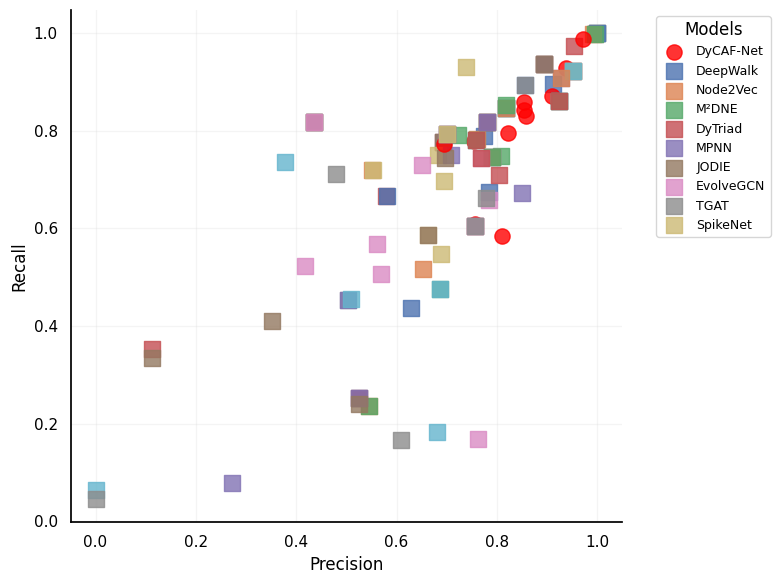

In [14]:
# ----------------------------
# 2. F1 Score Calculation & Precision-Recall Plot
# ----------------------------
def calculate_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Plot Precision vs Recall Trade-off and calculate F1-Score
plt.figure(figsize=(8, 6))
handled_models = set()  # To track which models we've already added to legend

for dataset in data:
    for model in data[dataset]:
        # Extract precision (index 0) and recall (index 1)
        prec, rec = data[dataset][model][0], data[dataset][model][1]
        f1_score = calculate_f1(prec, rec)

        # Append F1 score to the model's metrics (now at index 6)
        if len(data[dataset][model]) == 6:  # If F1 score not already added
            data[dataset][model].append(f1_score)

        # Custom markers and colors for better differentiation
        marker = 'o' if model == "DyCAF-Net" else 's'
        color = 'red' if model == "DyCAF-Net" else None

        # Only add label if we haven't shown this model before
        label = None
        if model not in handled_models:
            label = model
            handled_models.add(model)

        plt.scatter(prec, rec, s=120, marker=marker, color=color,
                    label=label, alpha=0.8)
        # Add F1 score as text annotation
        # plt.text(prec, rec, f'F1: {f1_score:.2f}', fontsize=8, ha='right', va='bottom')

# plt.title('Precision vs. Recall Trade-off Across Models and Datasets', fontsize=14)
plt.xlabel('Precision', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title="Models")
plt.grid(alpha=0.2)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()

plt.tight_layout()

# Save before showing
plt.savefig("Benchmarking1.pdf", bbox_inches='tight')
plt.show()

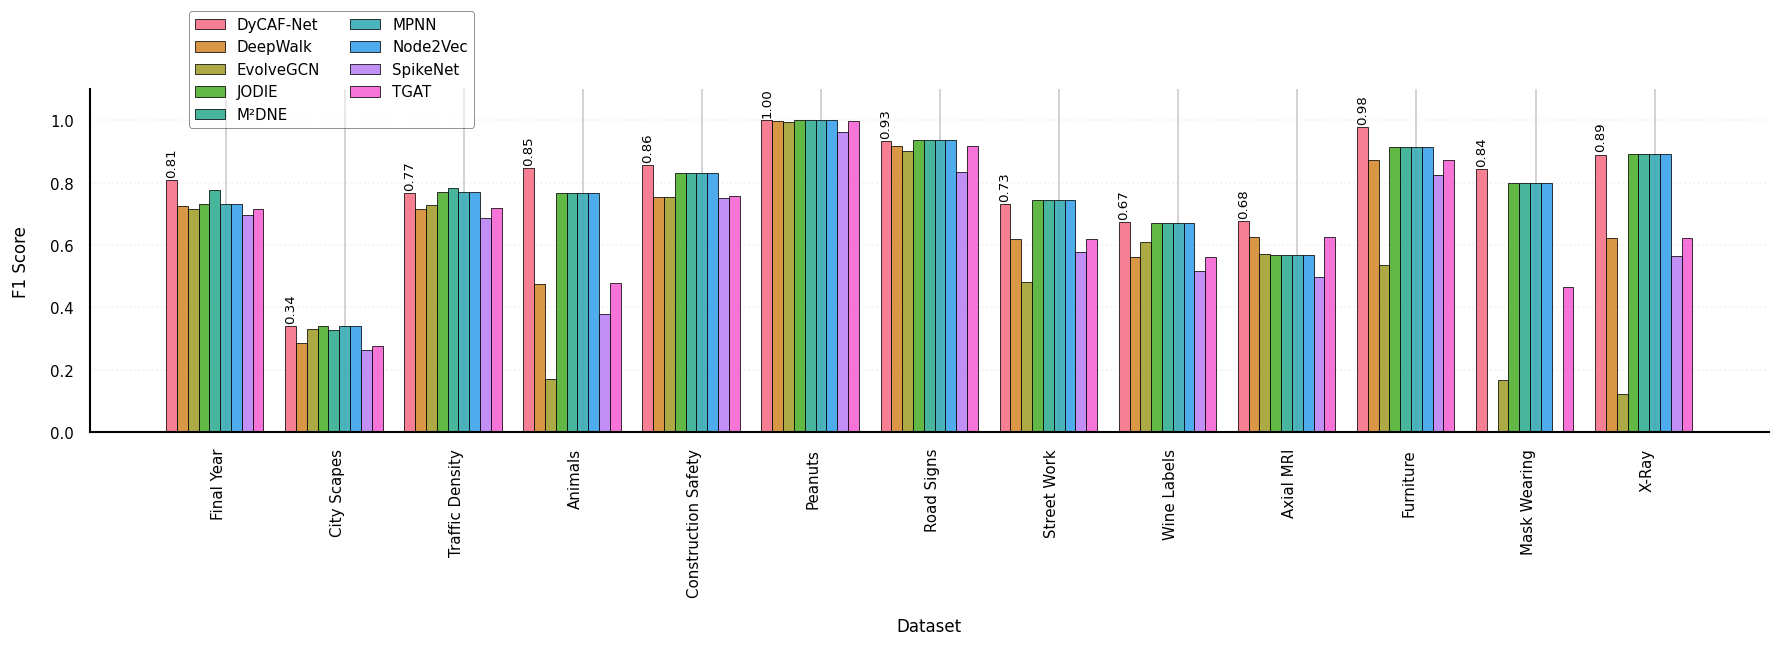

In [15]:
plt.figure(figsize=(15, 6), dpi=120)

# Define all models to include (sorted alphabetically except DyCAF-Net first)
all_models = ["DyCAF-Net", "DeepWalk", "EvolveGCN", "JODIE", "M²DNE",
              "MPNN", "Node2Vec", "SpikeNet", "TGAT"]

# Create a qualitative color palette
palette = sns.color_palette("husl", len(all_models))
model_colors = dict(zip(all_models, palette))

bar_width = 0.2
datasets = data.copy()
index = np.arange(len(datasets))
group_spacing = 0.4  # Space between dataset groups

# Calculate x positions with proper spacing
x_positions = index * (len(all_models) * bar_width + group_spacing)

# plt.title('F1-Score Comparison Across All Models', fontsize=14, pad=20)

# Plot each model's bars
for i, model in enumerate(all_models):
    f1_scores = [data[d][model][6] for d in datasets if model in data[d]]
    current_datasets = [d for d in datasets if model in data[d]]

    # Adjust x positions for available datasets
    pos_adjustment = np.array([list(datasets).index(d) for d in current_datasets])
    x = x_positions[pos_adjustment] + i * bar_width

    plt.bar(x, f1_scores, bar_width,
            label=model,
            color=model_colors[model],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.9)

# Add value labels for DyCAF-Net and YOLOv8 only (to reduce clutter)
for model in ["DyCAF-Net"]:
    if model in all_models:
        f1_scores = [data[d][model][6] for d in datasets if model in data[d]]
        current_datasets = [d for d in datasets if model in data[d]]
        pos_adjustment = np.array([list(datasets).index(d) for d in current_datasets])
        x = x_positions[pos_adjustment] + all_models.index(model) * bar_width

        for xi, yi in zip(x, f1_scores):
            plt.text(xi, yi + 0.01, f'{yi:.2f}',
                    ha='center', va='bottom',
                    fontsize=8, rotation=90)

# Configure axes and labels
plt.xlabel('Dataset', fontsize=10, labelpad=12)
plt.ylabel('F1 Score', fontsize=10, labelpad=12)
plt.xticks(x_positions + (len(all_models)-1) * (bar_width/2) + 0.2, datasets, rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 1.1)  # Leave room for value labels

# Add grid and reference line
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.axhline(y=0, color='gray', linewidth=0.5)

# Create legend outside plot
legend = plt.legend(ncol=2, frameon=True, fontsize=9,
                   bbox_to_anchor=(0.144, 1.25),
                   loc='upper center',
                   framealpha=0.5,
                   edgecolor='black')
legend.get_frame().set_linewidth(0.5)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()
plt.tight_layout()

# Save high-quality versions
plt.savefig("Benchmark4.pdf", bbox_inches='tight', dpi=300)
plt.show()

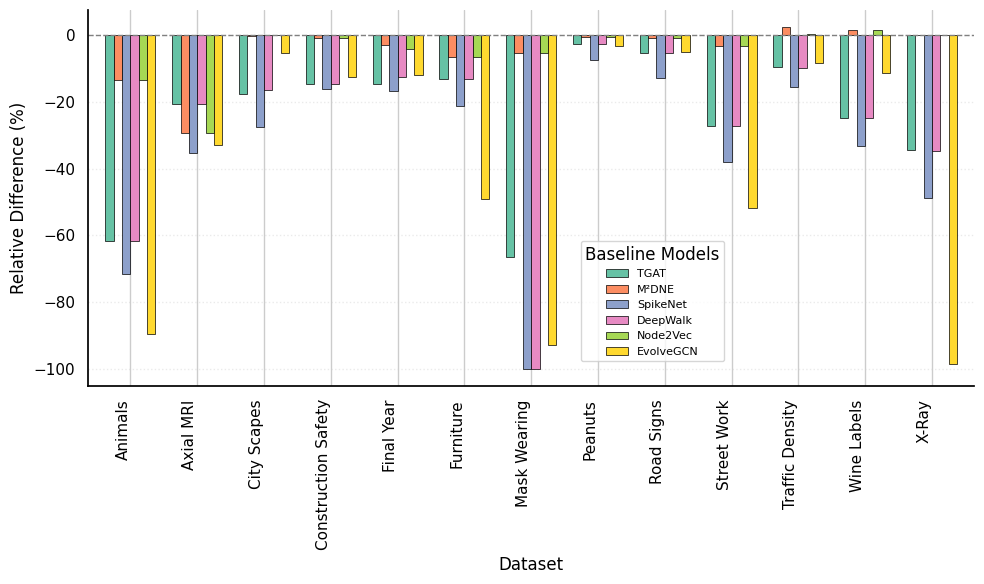

In [17]:
plt.figure(figsize=(10, 6))

# Configuration
all_models = ["TGAT", "M²DNE", "SpikeNet", "DeepWalk", "Node2Vec", "EvolveGCN"]
reference_model = "DyCAF-Net"
metric_index = 3  # mAP@50-95 is index 3 in your data structure
dataset_names = sorted(data.keys())  # Sort datasets alphabetically

# Spacing parameters
bar_width = 0.2
group_spacing = 0.4  # Space between different dataset groups
index = np.arange(len(dataset_names)) * (len(all_models) * bar_width + group_spacing)

# Calculate differences
diffs_by_model = {model: [] for model in all_models}
for dataset in dataset_names:
    dycaf_map = data[dataset][reference_model][metric_index]
    for model in all_models:
        model_map = data[dataset][model][metric_index]
        diff = ((model_map - dycaf_map) / dycaf_map) * 100
        diffs_by_model[model].append(diff)

# Plotting
palette = sns.color_palette("Set2", len(all_models))
for i, model in enumerate(all_models):
    plt.bar(index + i * bar_width, diffs_by_model[model],
            width=bar_width, label=model, color=palette[i],
            edgecolor='black', linewidth=0.5)

    # # Add value labels
    # for j, val in enumerate(diffs_by_model[model]):
    #     if abs(val) > 1:  # Only label significant differences
    #         va = 'bottom' if val >= 0 else 'top'
    #         y_offset = 1 if val >= 0 else -1
    #         plt.text(index[j] + i * bar_width, val + y_offset,
    #                 f'{val:.1f}%', ha='center', va=va,
    #                 fontsize=8, rotation=90)

# Reference lines
plt.axhline(0, color='gray', linewidth=1, linestyle='--')

# Formatting
# plt.title('mAP@50-95 Performance Relative to DyCAF-Net', fontsize=14, pad=20)
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Relative Difference (%)', fontsize=12)

# X-axis ticks centered between groups
plt.xticks(index + (len(all_models)-1) * bar_width/2,
          dataset_names, rotation=90, ha='right')

plt.legend(title="Baseline Models", fontsize=8,
          bbox_to_anchor=(0.55, 0.4), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.4)

# Adjust plot margins
plt.margins(x=0.02)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()
plt.tight_layout()

plt.savefig("Benchmark2.pdf", bbox_inches='tight', dpi=300)
plt.show()


Enhanced Leaderboard:


,Model,Avg mAP@50-95,Std mAP,Min mAP,Max mAP,Params (M),Avg Time (ms),Avg FPS
0,DyCAF-Net,0.596,0.198,0.153000,0.926300,11.13,14.6,68.3
2,M²DNE,0.569,0.197,0.152700,0.920700,11.13,11.3,88.3
5,Node2Vec,0.567,0.197,0.153000,0.920700,11.13,11.7,85.4
1,TGAT,0.455,0.220,0.126000,0.901000,11.13,12.0,83.1
4,DeepWalk,0.440,0.244,0.000300,0.900900,11.13,14.8,67.5
3,SpikeNet,0.396,0.236,0.000200,0.857000,3.01,8.3,119.9
6,EvolveGCN,0.369,0.262,0.008500,0.894800,11.13,11.9,83.8


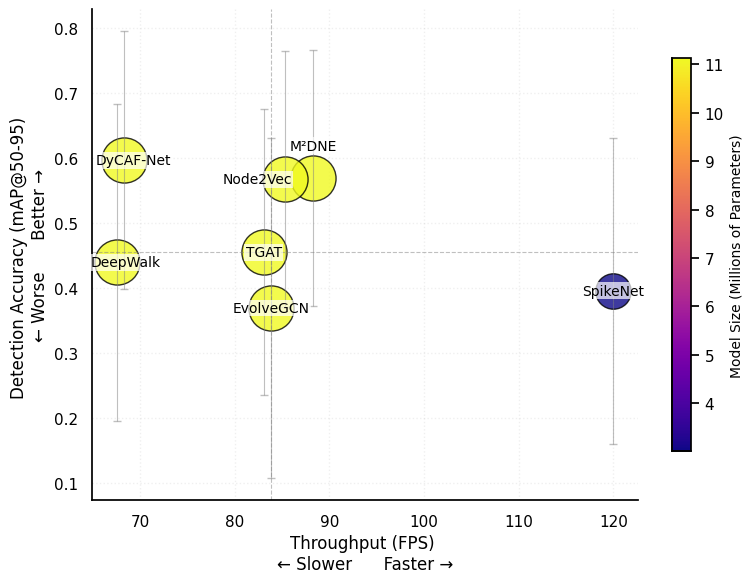

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------
# 4. Enhanced Leaderboard Table
# ----------------------------
models_to_compare = ["DyCAF-Net", "TGAT", "M²DNE", "SpikeNet", "DeepWalk", "Node2Vec", "EvolveGCN"]
leaderboard_data = []

for model in models_to_compare:
    # Calculate statistics
    maps = [data[d][model][3] for d in data if model in data[d]]  # mAP@50-95 is index 3
    params = [data[d][model][4] for d in data if model in data[d]]
    times = [data[d][model][5] for d in data if model in data[d]]  # Time is index 5

    leaderboard_data.append({
        "Model": model,
        "Avg mAP@50-95": np.mean(maps),
        "Std mAP": np.std(maps),
        "Min mAP": np.min(maps),
        "Max mAP": np.max(maps),
        "Params (M)": np.mean(params)/1e6,  # Convert to millions
        "Avg Time (ms)": np.mean(times),
        "Avg FPS": 1000/np.mean(times)
    })

# Create and sort the leaderboard DataFrame
df = pd.DataFrame(leaderboard_data)
df = df.sort_values("Avg mAP@50-95", ascending=False)

# Format the table display
styled_df = df.style \
    .background_gradient(subset=["Avg mAP@50-95"], cmap="YlGn") \
    .format({
        "Avg mAP@50-95": "{:.3f}",
        "Std mAP": "{:.3f}",
        "Params (M)": "{:.2f}",
        "Avg Time (ms)": "{:.1f}",
        "Avg FPS": "{:.1f}"
    }) \
    .set_caption("Model Performance Leaderboard") \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14pt'), ('font-weight', 'bold')]
    }])

print("\nEnhanced Leaderboard:")
display(styled_df)

# Save table as image
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.table(cellText=df.round(3).values,
         colLabels=df.columns,
         cellLoc='center',
         loc='center',
         colColours=["#f7f7f7"]*len(df.columns))
plt.tight_layout()
plt.savefig("Leaderboard.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ----------------------------
# 5. Enhanced Speed-Accuracy Trade-off
# ----------------------------
plt.figure(figsize=(8, 6))

# Create colormap based on parameter count
param_counts = [data[list(data.keys())[0]][m][4]/1e6 for m in models_to_compare]
norm = plt.Normalize(min(param_counts), max(param_counts))
cmap = plt.get_cmap("plasma")

# We'll use a text offset algorithm to prevent label overlap
text_offsets = {
    "DyCAF-Net": (1, 0),
    "TGAT": (0, 0),
    "M2DNE": (2, -1),
    "SpikeNet": (0, 0),
    "DeepWalk": (1, 0),
    "Node2Vec": (-3, 0),
    "EvolveGCN": (0, 0)
}


for model in models_to_compare:
    # Calculate statistics
    times = [data[d][model][5] for d in data if model in data[d]]
    maps = [data[d][model][3] for d in data if model in data[d]]

    avg_fps = 1000/np.mean(times)
    avg_map = np.mean(maps)
    std_map = np.std(maps)
    param_size = data[list(data.keys())[0]][model][4]/1e6  # Parameters in millions

    # Plot with error bars and size based on parameters
    plt.scatter(avg_fps, avg_map,
               s=500 + param_size*50,  # Size reflects parameter count
               c=[cmap(norm(param_size))],
               label=model,
               edgecolors='black',
               linewidth=1,
               alpha=0.8)

    # Add error bars for mAP variability
    plt.errorbar(avg_fps, avg_map,
                yerr=std_map,
                fmt='none',
                ecolor='gray',
                elinewidth=0.8,
                capsize=3,
                alpha=0.5)

    # Add model labels with small offset
    # plt.text(avg_fps, avg_map+0.01, model,
    #         fontsize=5, ha='center', va='bottom')

    # Add non-overlapping labels with custom offsets
    offset = text_offsets.get(model, (0, 0.05))
    plt.text(avg_fps + offset[0], avg_map + offset[1], model,
            fontsize=10, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Add colorbar for parameter size
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
cbar.set_label('Model Size (Millions of Parameters)', fontsize=10)

# plt.title('Model Efficiency: Speed-Accuracy Trade-off', fontsize=14, pad=20)
plt.xlabel('Throughput (FPS) \n← Slower      Faster →', fontsize=12)
plt.ylabel('Detection Accuracy (mAP@50-95) \n← Worse      Better →', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.3)

# Add benchmark reference lines
plt.axhline(y=df['Avg mAP@50-95'].median(), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axvline(x=df['Avg FPS'].median(), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()
plt.tight_layout()
plt.savefig("Benchmark3.pdf", bbox_inches='tight', dpi=300)
plt.show()

# Ablation

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = {
    "Construction Safety": {
        "DyCAF-Net": [0.8545, 0.8583, 0.9023, 0.5195, 11127519, 11.9],
        "w/o Equilibrium": [0.8292, 0.8448, 0.8844, 0.5172, 11127519, 13.7],
        "w/o Dual attention": [0.8292, 0.8448, 0.8844, 0.5172, 11127519, 10.6],
        "w/o Class_aware": [0.8214, 0.6940, 0.7668, 0.4396, 11127519, 10.6]
    },
    "Final Year": {
        "DyCAF-Net": [0.8221, 0.7966, 0.8232, 0.5743, 11127906, 11.2],
        "w/o Equilibrium": [0.7940, 0.7150, 0.7890, 0.5530, 11127906, 13.9],
        "w/o Dual attention": [0.7940, 0.7650, 0.7970, 0.5600, 11127906, 11.2],
        "w/o Class_aware": [0.7360, 0.7130, 0.7350, 0.4850, 11127906, 11.1]
    },
    "Traffic Density": {
        "DyCAF-Net": [0.7538, 0.7788, 0.8176, 0.5466, 11128680, 13.5],
        "w/o Equilibrium": [0.7453, 0.7720, 0.8175, 0.5447, 11128680, 11.3], ######
        "w/o Dual attention": [0.7453, 0.7720, 0.8175, 0.5447, 11128680, 11.1],
        "w/o Class_aware": [0.6888, 0.7481, 0.7709, 0.4929, 11128680, 11.3]
    },
    "Street Work": {
        "DyCAF-Net": [0.6936, 0.7737, 0.6943, 0.4575, 11128680, 13.6], #######
        "w/o Equilibrium": [0.6916, 0.7126, 0.6117, 0.3666, 11128680, 13.6],
        "w/o Dual attention": [0.6916, 0.7126, 0.6117, 0.3666, 11128680, 12.3],
        "w/o Class_aware": [0.6454, 0.5810, 0.5661, 0.3274, 11128680, 11.6]
    },
    "Mask Wearing": {
        "DyCAF-Net": [0.8582, 0.8299, 0.9266, 0.6424, 11126358, 13.0], #######
        "w/o Equilibrium": [0.8427, 0.8290, 0.9023, 0.6249, 11126358, 14.1],
        "w/o Dual attention": [0.8427, 0.8290, 0.9023, 0.6249, 11126358, 13.9],
        "w/o Class_aware": [0.5590, 0.3960, 0.4572, 0.2243, 11126358, 14.2]
    },
    "City Scapes": {
        "DyCAF-Net": [0.5251, 0.2522, 0.2509, 0.1530, 11127906, 6.3],
        "w/o Equilibrium": [0.3268, 0.2545, 0.2478, 0.1544, 11127906, 6.4],
        "w/o Dual attention": [0.3268, 0.2545, 0.2478, 0.1544, 11127906, 6.2],
        "w/o Class_aware": [0.6383, 0.1899, 0.2060, 0.1283, 11127906, 6.3]
    },
    "Furniture": {
        "DyCAF-Net": [0.9706, 0.9891, 0.9941, 0.8691, 11126745, 14.3],
        "w/o Equilibrium": [0.9723, 0.9819, 0.9948, 0.9039, 11126745, 14.6],
        "w/o Dual attention": [0.9723, 0.9819, 0.9948, 0.9039, 11126745, 13.9],
        "w/o Class_aware": [0.9224, 0.8618, 0.9498, 0.7685, 11126745, 13.9]
    },
    "Peanuts": {
        "DyCAF-Net": [0.9999, 1.0000, 0.9950, 0.9263, 11126358, 38.2],
        "w/o Equilibrium": [0.9999, 1.0000, 0.9950, 0.9197, 11126358, 36.7],
        "w/o Dual attention": [0.9999, 1.0000, 0.9950, 0.9197, 11126358, 8.0],
        "w/o Class_aware": [0.9994, 0.9995, 0.9950, 0.9054, 11126358, 8.1]
    },
    "Road Signs": {
        "DyCAF-Net": [0.9377, 0.9295, 0.9676, 0.8200, 11133711, 12.6],
        "w/o Equilibrium": [0.9361, 0.9321, 0.9680, 0.8186, 11133711, 12.7],
        "w/o Dual attention": [0.9361, 0.9321, 0.9680, 0.8186, 11133711, 12.8],
        "w/o Class_aware": [0.9360, 0.8927, 0.9536, 0.7879, 11133711, 12.4]
    },
    "Wine Labels": {
        "DyCAF-Net": [0.7557, 0.6087, 0.6435, 0.4557, 11130228, 12.0],
        "w/o Equilibrium": [0.7500, 0.5930, 0.6400, 0.4550, 11130228, 14.3],
        "w/o Dual attention": [0.7500, 0.5930, 0.6400, 0.4550, 11130228, 12.7],
        "w/o Class_aware": [0.6880, 0.4800, 0.4960, 0.3520, 11130228, 12.7]
    },
    "Axials MRI": {
        "DyCAF-Net": [0.8090, 0.5841, 0.6749, 0.4815, 11126358, 16.5],
        "w/o Equilibrium": [0.5500, 0.7340, 0.5770, 0.3900, 11126358, 15.6],
        "w/o Dual attention": [0.5500, 0.7340, 0.5770, 0.3900, 11126358, 13.2],
        "w/o Class_aware": [0.5930, 0.6960, 0.6680, 0.4130, 11126358, 13.2]
    },
    "X-Ray": {
        "DyCAF-Net": [0.9105, 0.8717, 0.8593, 0.5774, 11130228, 13.6],
        "w/o Equilibrium": [0.8910, 0.8860, 0.9080, 0.5890, 11130228, 24.9],
        "w/o Dual attention": [0.8910, 0.8860, 0.9080, 0.5890, 11130228, 14.0],
        "w/o Class_aware": [0.6580, 0.6100, 0.6600, 0.3740, 11130228, 14.8]
    },
    "Animals": {
        "DyCAF-Net": [0.8541, 0.8429, 0.8970, 0.7305, 11129454, 13.5],
        "w/o Equilibrium": [0.7820, 0.8350, 0.8620, 0.6730, 11129454, 12.9],
        "w/o Dual attention": [0.7820, 0.8350, 0.8620, 0.6730, 11129454, 10.4],
        "w/o Class_aware": [0.4660, 0.4320, 0.4480, 0.2930, 11129454, 10.8]
    }
}


# Initialize styling for visualizations
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "DejaVu Sans"

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set default font color and other styles
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',  # Also ensures the axes spines are black
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})


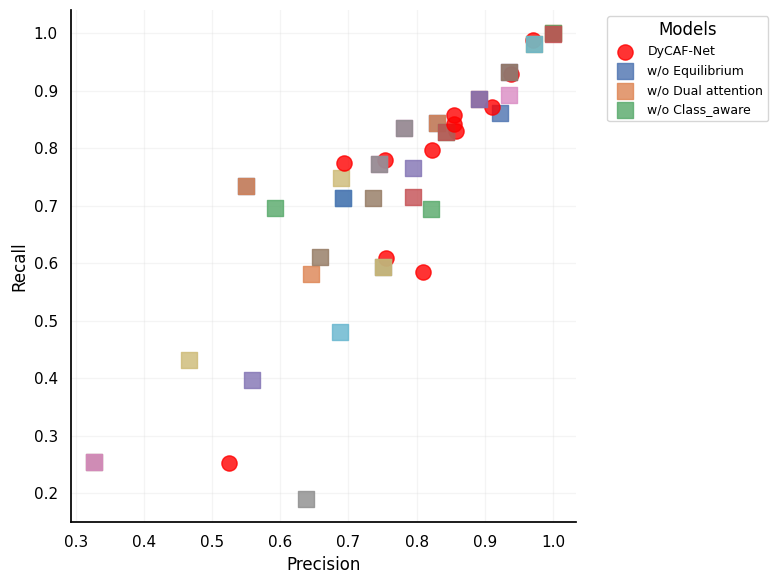

In [21]:
# ----------------------------
# 2. F1 Score Calculation & Precision-Recall Plot
# ----------------------------
def calculate_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Plot Precision vs Recall Trade-off and calculate F1-Score
plt.figure(figsize=(8, 6))
handled_models = set()  # To track which models we've already added to legend

for dataset in data:
    for model in data[dataset]:
        # Extract precision (index 0) and recall (index 1)
        prec, rec = data[dataset][model][0], data[dataset][model][1]
        f1_score = calculate_f1(prec, rec)

        # Append F1 score to the model's metrics (now at index 6)
        if len(data[dataset][model]) == 6:  # If F1 score not already added
            data[dataset][model].append(f1_score)

        # Custom markers and colors for better differentiation
        marker = 'o' if model == "DyCAF-Net" else 's'
        color = 'red' if model == "DyCAF-Net" else None

        # Only add label if we haven't shown this model before
        label = None
        if model not in handled_models:
            label = model
            handled_models.add(model)

        plt.scatter(prec, rec, s=120, marker=marker, color=color,
                    label=label, alpha=0.8)
        # Add F1 score as text annotation
        # plt.text(prec, rec, f'F1: {f1_score:.2f}', fontsize=8, ha='right', va='bottom')

# plt.title('Precision vs. Recall Trade-off Across Models and Datasets', fontsize=14)
plt.xlabel('Precision', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title="Models")
plt.grid(alpha=0.2)
# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()
plt.tight_layout()

plt.show()

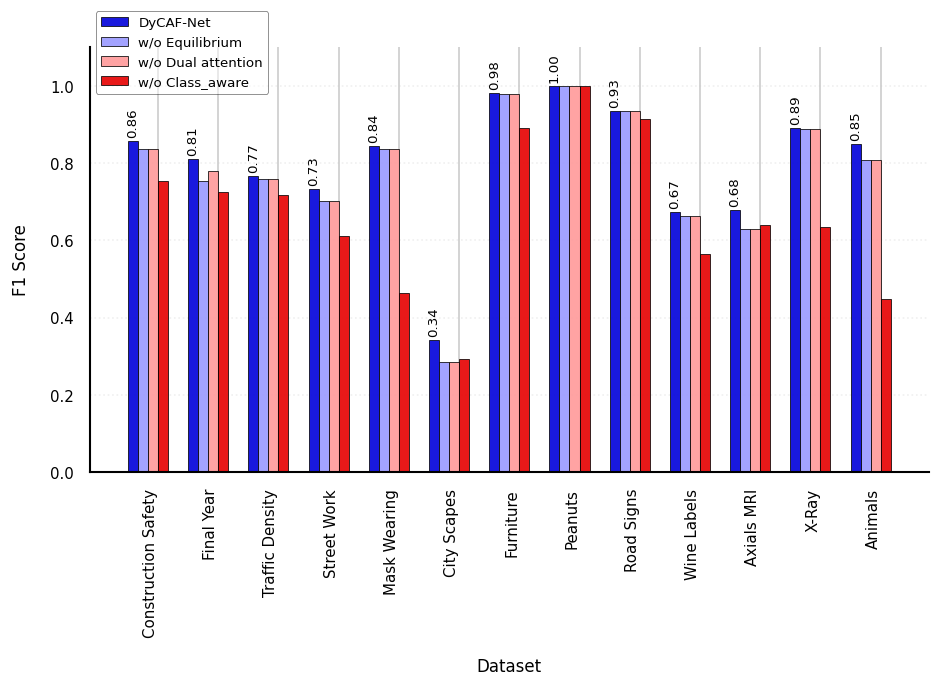

In [22]:
plt.figure(figsize=(8, 6), dpi=120)

# Define all models to include
all_models = ["DyCAF-Net", "w/o Equilibrium", "w/o Dual attention", "w/o Class_aware"]

# Create a qualitative color palette
palette = sns.color_palette("seismic", len(all_models))
model_colors = dict(zip(all_models, palette))

bar_width = 0.2
datasets = data.copy()
index = np.arange(len(datasets))
group_spacing = 0.4  # Space between dataset groups


# Calculate x positions with proper spacing
x_positions = index * (len(all_models) * bar_width + group_spacing)

# plt.title('Ablation of DyCAF-Net Using F1-Score', fontsize=14, pad=20)

# Plot each model's bars
for i, model in enumerate(all_models):
    f1_scores = [data[d][model][6] for d in datasets if model in data[d]]
    current_datasets = [d for d in datasets if model in data[d]]

    # Adjust x positions for available datasets
    pos_adjustment = np.array([list(datasets).index(d) for d in current_datasets])
    x = x_positions[pos_adjustment] + i * bar_width

    plt.bar(x, f1_scores, bar_width,
            label=model,
            color=model_colors[model],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.9)

# Add value labels for DyCAF-Net and YOLOv8 only (to reduce clutter)
for model in ["DyCAF-Net"]:
    if model in all_models:
        f1_scores = [data[d][model][6] for d in datasets if model in data[d]]
        current_datasets = [d for d in datasets if model in data[d]]
        pos_adjustment = np.array([list(datasets).index(d) for d in current_datasets])
        x = x_positions[pos_adjustment] + all_models.index(model) * bar_width

        for xi, yi in zip(x, f1_scores):
            plt.text(xi, yi + 0.01, f'{yi:.2f}',
                    ha='center', va='bottom',
                    fontsize=8, rotation=90)

# Configure axes and labels
plt.xlabel('Dataset', fontsize=10, labelpad=12)
plt.ylabel('F1 Score', fontsize=10, labelpad=12)
plt.xticks(x_positions + (len(all_models)-1) * (bar_width/2) + 0.2, datasets, rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 1.1)  # Leave room for value labels

# Add grid and reference line
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.axhline(y=0, color='gray', linewidth=0.5)

# Create legend outside plot
legend = plt.legend(ncol=1, frameon=True, fontsize=8,
                   bbox_to_anchor=(0.11, 1.1),
                   loc='upper center',
                   framealpha=0.5,
                   edgecolor='black')
legend.get_frame().set_linewidth(0.5)

# Make axes black
for spine in plt.gca().spines.values():
    spine.set_color('black')

sns.despine()
plt.tight_layout()

# Save high-quality versions
plt.savefig("ablation.pdf", bbox_inches='tight', dpi=300)
plt.show()